In [4]:
import pandas as pd

df = pd.read_csv("data/SPX_data_26.02.24.csv")

In [5]:
df.head(5)

,underlying_symbol,quote_datetime,root,expiration,strike,option_type,open,high,low,close,trade_volume,bid_size,bid,ask_size,ask,underlying_bid,underlying_ask,open_interest,time_to_maturity
0,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,200.0,C,0.0,0.0,0.0,0.0,0,2,6673.0,1,6692.9,6852.66,6913.22,35,0.063014
1,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,400.0,C,0.0,0.0,0.0,0.0,0,1,6473.3,1,6492.5,6852.66,6913.22,13,0.063014
2,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,600.0,C,0.0,0.0,0.0,0.0,0,1,6273.5,1,6294.5,6852.66,6913.22,6,0.063014
3,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,800.0,C,0.0,0.0,0.0,0.0,0,2,6074.7,1,6093.2,6852.66,6913.22,9,0.063014
4,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,1000.0,C,0.0,0.0,0.0,0.0,0,10,5877.8,10,5892.1,6852.66,6913.22,1101,0.063014


Volatility smile & term structure

In [7]:
from src.black_scholes import implied_volatility

df['C_mkt'] = (df['bid'] + df['ask']) / 2
df['S_0'] = (df['underlying_bid'] + df['underlying_ask']) / 2
r_annual = 0.045

# compute implied volatility for each row in the dataframe
df['implied_vol'] = df.apply(
    lambda row: implied_volatility(row['C_mkt'], row['S_0'], row['strike'], row['time_to_maturity'], r_annual),
    axis=1
)

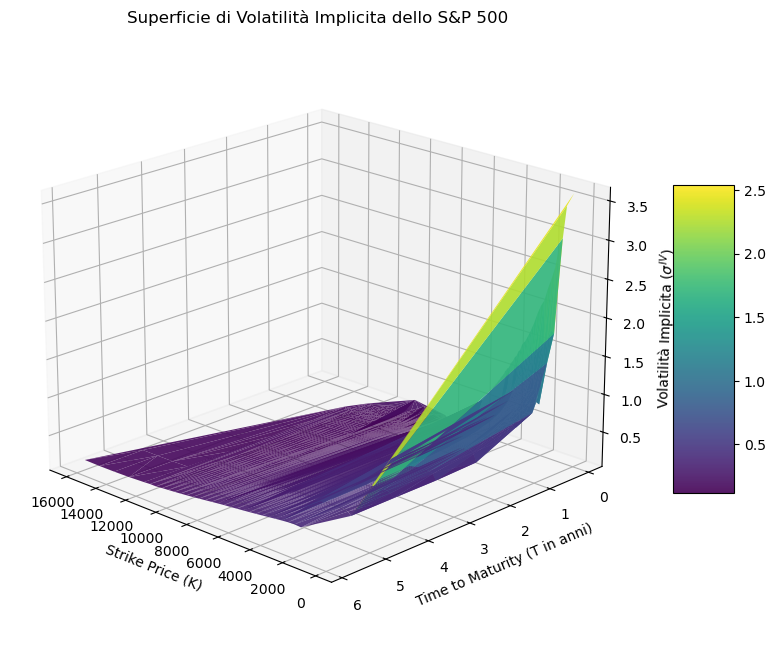

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Applica prima i filtri di pulizia (bid > 0, ask > 0, spread sensato)
df_clean = df[(df['bid'] > 0) & (df['ask'] > 0)].copy()
df_clean['IV'] = df_clean['implied_vol'] # la colonna calcolata
df_clean = df_clean.dropna(subset=['IV'])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Creiamo la superficie tridimensionale
surf = ax.plot_trisurf(df_clean['strike'], df_clean['time_to_maturity'], df_clean['IV'], 
                       cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_xlabel('Strike Price (K)')
ax.set_ylabel('Time to Maturity (T in anni)')
ax.set_zlabel('Volatilità Implicita ($\sigma^{IV}$)')
ax.set_title('Superficie di Volatilità Implicita dello S&P 500')

# Aggiunge la barra dei colori
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
ax.view_init(elev=20, azim=134) # Ruota per vedere bene lo skew

plt.show()

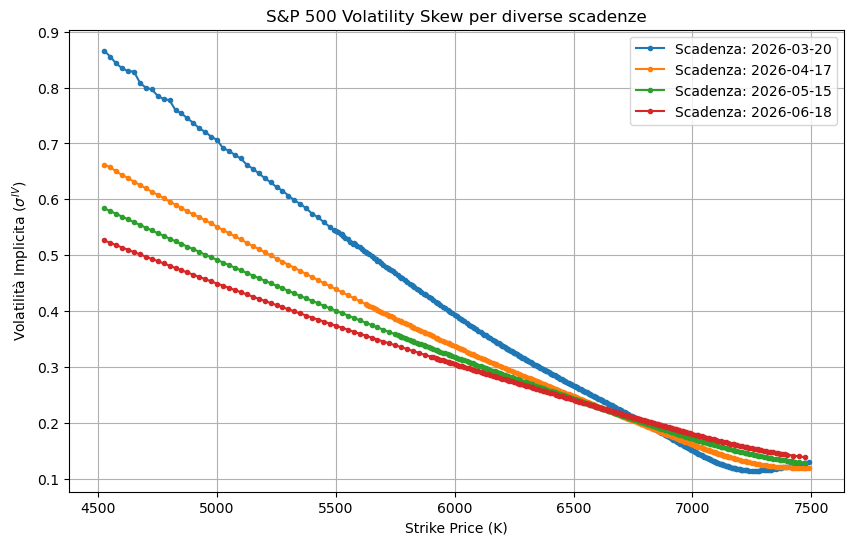

In [25]:
plt.figure(figsize=(10, 6))

# Prendiamo le scadenze uniche disponibili e ne scegliamo alcune significative
scadenze_uniche = sorted(df_clean['expiration'].unique())

for scadenza in scadenze_uniche[:4]: # Mostriamo le prime 4 scadenze come esempio
    df_sub = df_clean[df_clean['expiration'] == scadenza].sort_values(by='strike')
    
    # Visualizziamo solo la zona centrale (ATM) per evitare rumore dagli estremi
    df_sub = df_sub[(df_sub['strike'] > 4500) & (df_sub['strike'] < 7500)]
    
    plt.plot(df_sub['strike'], df_sub['IV'], label=f'Scadenza: {scadenza}', marker='o', markersize=3)

plt.title('S&P 500 Volatility Skew per diverse scadenze')
plt.xlabel('Strike Price (K)')
plt.ylabel('Volatilità Implicita ($\sigma^{IV}$)')
plt.grid(True)
plt.legend()
plt.show()

### Part 2: Heston model

In [ ]:
import numpy as np
import pandas as pd
import src.heston as hst
from tqdm import tqdm  

# extract the bounds for the parameters from the real datasetpip
df['S0_mid'] = (df['underlying_bid'] + df['underlying_ask']) / 2
S0_mercato = df['S0_mid'].mean()

tasso_risk_free = 0.045 

T_min = df['time_to_maturity'].min()
T_max = df['time_to_maturity'].max()

df['moneyness_real'] = df['strike'] / df['S0_mid']
moneyness_min = df['moneyness_real'].min()
moneyness_max = df['moneyness_real'].max()

df_atm = df[(df['moneyness_real'] >= 0.98) & (df['moneyness_real'] <= 1.02)]
iv_min = df_atm['implied_vol'].min()
iv_max = df_atm['implied_vol'].max()

variance_min = max(0.005, iv_min ** 2)  
variance_max = min(0.25, iv_max ** 2)   

N_SAMPLES = 20000
dataset_rows = []

print("Generating synthetic dataset.")

for i in tqdm(range(N_SAMPLES), desc="Samples generated:"):
    kappa_casuale = np.random.uniform(0.1, 5.0)
    xi_casuale = np.random.uniform(0.05, 1.0)
    rho_casuale = np.random.uniform(-0.95, 0.0) 
    
    theta_casuale = np.random.uniform(variance_min, variance_max)
    V0_casuale = np.random.uniform(variance_min, variance_max)
    
    maturity_casuale = np.random.uniform(T_min, T_max)
    moneyness = np.random.uniform(moneyness_min, moneyness_max)
    strike_casuale = S0_mercato * moneyness
    
    try:
        synthetic_price = hst.heston_call_price(
            S0=S0_mercato, 
            K=strike_casuale, 
            T=maturity_casuale, 
            r=tasso_risk_free, 
            kappa=kappa_casuale, 
            theta=theta_casuale, 
            xi=xi_casuale, 
            rho=rho_casuale, 
            V0=V0_casuale
        )

        target_iv = implied_volatility(synthetic_price, S0_mercato, strike_casuale, maturity_casuale, tasso_risk_free)

        if not np.isnan(target_iv) and target_iv > 0:
            dataset_rows.append([kappa_casuale, theta_casuale, xi_casuale, rho_casuale, V0_casuale, 
                             strike_casuale, maturity_casuale, target_iv])
    except:
        continue

columns = ['kappa', 'theta', 'xi', 'rho', 'V0', 'strike', 'time_to_maturity', 'target_iv']
df_sintetico = pd.DataFrame(dataset_rows, columns=columns)

# save in a csv file
df_sintetico.to_csv('heston_synthetic_dataset.csv', index=False)
print(f"\nGeneration completed and saved. Samples generated: {len(df_sintetico)}.")

Generating synthetic dataset.


Samples generated::  22%|██▏       | 4386/20000 [03:12<13:32, 19.22it/s]c:\Users\camil\Documents\AIF_project\src\heston.py:80: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  P1 = 0.5 + (1 / np.pi) * integrate.quad(int_1, 1e-5, 100, limit=200)[0]
c:\Users\camil\Documents\AIF_project\src\heston.py:81: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, di


Generation completed and saved. Samples generated: 14119.


In [9]:
df_sintetico.to_csv('data/heston_synthetic_dataset.csv', index=False)

print(f"\n Dataset saved as 'data/heston_synthetic_dataset.csv'.")


 Dataset saved as 'data/heston_synthetic_dataset.csv'.


In [1]:
import src.nn_for_volatility as hst_nn

model, scaler = hst_nn.train_heston_model(
    csv_path='data/heston_synthetic_dataset.csv', 
    epochs=60, 
    batch_size=64, 
    patience=5
)

: 